<a href="https://colab.research.google.com/github/rajeshxdatascience/Car-Price-Prediction-ML/blob/main/02_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [123]:
import pandas as pd
import numpy as np


In [124]:
df = pd.read_parquet("/content/car_price_prediction.parquet")
df = pd.get_dummies(df, drop_first=True)

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3550 entries, 0 to 3549
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   km_driven                   3550 non-null   float64
 1   car_age                     3550 non-null   int64  
 2   log_price                   3550 non-null   float64
 3   brand_bmw                   3550 non-null   bool   
 4   brand_chevrolet             3550 non-null   bool   
 5   brand_datsun                3550 non-null   bool   
 6   brand_fiat                  3550 non-null   bool   
 7   brand_ford                  3550 non-null   bool   
 8   brand_honda                 3550 non-null   bool   
 9   brand_hyundai               3550 non-null   bool   
 10  brand_mahindra              3550 non-null   bool   
 11  brand_maruti                3550 non-null   bool   
 12  brand_mercedes-benz         3550 non-null   bool   
 13  brand_nissan                3550 

In [126]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [127]:
X = df.drop('log_price',axis=1)
y = df['log_price']

X_train, X_test , y_train, y_test = train_test_split(X, y , test_size=0.2,random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [128]:
y_pred = lr.predict(X_test)

In [129]:
print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
print("R2 Score", r2_score(y_test,y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test,y_pred)))

MAE 0.30584805786819597
MSE 0.14798027049277065
R2 Score 0.7840409786174871
RMSE 0.38468203817278845


In [130]:
lr.coef_

array([-1.14429635e-06, -1.10126713e-01, -9.21715484e-02, -1.42203183e+00,
       -1.47240001e+00, -1.39699245e+00, -1.08386677e+00, -8.58860637e-01,
       -1.06161139e+00, -9.05299455e-01, -1.17546534e+00,  1.79677718e-01,
       -1.10999885e+00, -2.69780263e-01, -1.22541903e+00, -9.61028865e-01,
       -1.55627827e+00, -4.84598617e-01, -1.01224239e+00, -1.29552758e-01,
       -4.85570713e-02, -1.33309100e-01, -1.00093353e-01, -4.27962297e-01,
       -5.07472682e-01, -4.31770123e-01])

In [131]:
lr.intercept_

np.float64(16.03629943305918)

Text(0.5, 1.0, 'Actual vs Predicted')

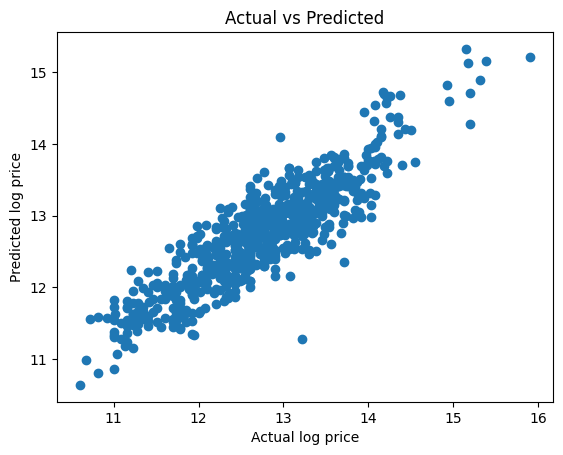

In [132]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual log price")
plt.ylabel("Predicted log price")
plt.title("Actual vs Predicted")

In [133]:
X_test.shape

(710, 26)

In [134]:
r2 = r2_score(y_test,y_pred)


In [135]:
print("Adjusted R2 Score",1 - ((1 - r2)*(710-1))/(710-1-26))

Adjusted R2 Score 0.7758199909806711


Text(0, 0.5, 'Residuals')

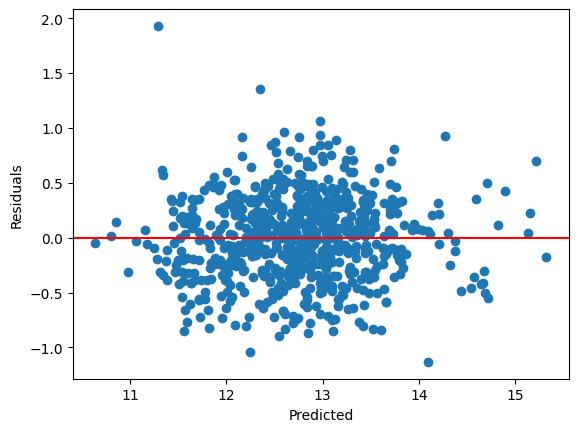

In [136]:
plt.scatter(y_pred, y_test - y_pred)
plt.axhline(0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")

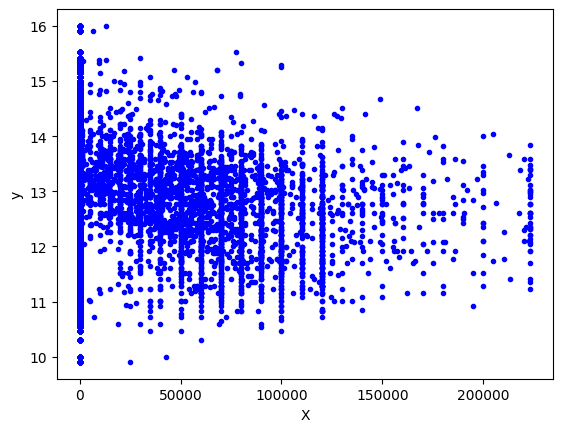

In [137]:
plt.plot(X, y, 'b. ')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

Text(0.5, 1.0, 'Actual vs Predicted')

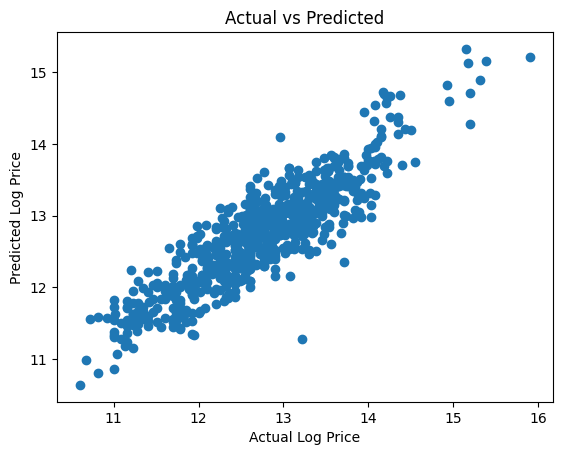

In [138]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted")

In [139]:
df_numeric = df.astype(float)

condition_number = np.linalg.cond(df_numeric)
print("Condition Number:", condition_number)

Condition Number: 3527630.372070348


In [140]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Saare columns ko numeric (int/float) mein convert karein
# Isse Boolean values 0 aur 1 mein badal jayengi
X_vif = X.astype(int)

# 2. VIF calculate karein
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 3. Sort karke display karein
print(vif_data.sort_values(by="VIF", ascending=False))

                       Feature        VIF
1                      car_age  16.250104
23         transmission_manual  16.117300
10                brand_maruti   9.409478
0                    km_driven   5.723732
8                brand_hyundai   5.605219
22      seller_type_individual   5.500741
16                  brand_tata   3.438923
9               brand_mahindra   3.258398
25                 fuel_petrol   2.920632
7                  brand_honda   2.402161
6                   brand_ford   2.347188
3              brand_chevrolet   2.204947
17                brand_toyota   2.160280
20          owner_second owner   1.754380
14               brand_renault   1.745719
18            brand_volkswagen   1.550853
12                brand_nissan   1.374094
21           owner_third owner   1.332775
5                   brand_fiat   1.253402
15                 brand_skoda   1.253373
4                 brand_datsun   1.212525
13                 brand_other   1.139571
19  owner_fourth & above owner   1

In [141]:
import statsmodels.api as sm

# Constant add karna mat bhulna (Intercept ke liye)
X_train_sm = sm.add_constant(X_train.astype(float))
model = sm.OLS(y_train, X_train_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     371.5
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:21:36   Log-Likelihood:                -1336.9
No. Observations:                2840   AIC:                             2728.
Df Residuals:                    2813   BIC:                             2889.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [173]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd

# 1. Columns drop karne wala step skip karein (Kyunki 83% accuracy chahiye)
# X_optimized = X  # Direct use karein

# 2. Scaling apply karein (Pure 26 features par)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X should have all 26 features

# 3. DataFrame aur Constant add karein
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
X_final = sm.add_constant(X_scaled_df)

# 4. Model Re-run
final_model = sm.OLS(y, X_final).fit()
print(final_model.summary())

# Iske baad jab aap sklearn ka LinearRegression fit karenge:
# final_lr.fit(X_train, y_train) # Make sure X_train also has 26 features

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     471.7
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:43:38   Log-Likelihood:                -1663.0
No. Observations:                3550   AIC:                             3380.
Df Residuals:                    3523   BIC:                             3547.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [174]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Saare columns ko numeric (int/float) mein convert karein
# Isse Boolean values 0 aur 1 mein badal jayengi
X_vif = X.astype(int)

# 2. VIF calculate karein
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 3. Sort karke display karein
print(vif_data.sort_values(by="VIF", ascending=False))

                       Feature        VIF
1                      car_age  16.250104
23         transmission_manual  16.117300
10                brand_maruti   9.409478
0                    km_driven   5.723732
8                brand_hyundai   5.605219
22      seller_type_individual   5.500741
16                  brand_tata   3.438923
9               brand_mahindra   3.258398
25                 fuel_petrol   2.920632
7                  brand_honda   2.402161
6                   brand_ford   2.347188
3              brand_chevrolet   2.204947
17                brand_toyota   2.160280
20          owner_second owner   1.754380
14               brand_renault   1.745719
18            brand_volkswagen   1.550853
12                brand_nissan   1.374094
21           owner_third owner   1.332775
5                   brand_fiat   1.253402
15                 brand_skoda   1.253373
4                 brand_datsun   1.212525
13                 brand_other   1.139571
19  owner_fourth & above owner   1

In [175]:
# 1. Calculate Cook's Distance
influence = final_model.get_influence()
cooks = influence.cooks_distance[0]

# 2. Threshold set karein (Standard: 4/n)
n = X_final.shape[0]
threshold = 4/n

# 3. Identify outliers
outliers = np.where(cooks > threshold)[0]
print(f"Total Outliers identified: {len(outliers)}")

# 4. Remove outliers and re-train
X_no_outliers = X_final.drop(X_final.index[outliers])
y_no_outliers = y.drop(y.index[outliers])

final_model_v2 = sm.OLS(y_no_outliers, X_no_outliers).fit()
print(final_model_v2.summary())

Total Outliers identified: 194
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     536.8
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:43:50   Log-Likelihood:                -1149.3
No. Observations:                3356   AIC:                             2353.
Df Residuals:                    3329   BIC:                             2518.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [176]:
# 1. Outliers ke indices pakdein (Cook's distance ke basis par)
outliers_indices = X_final.index[outliers]

# 2. Apne main Dataframe se in rows ko drop karein
# Maan lijiye aapka original cleaned dataframe 'df' hai
df_clean = df.drop(index=outliers_indices)

# 3. Target aur Features ko phir se define karein
y_final = df_clean['log_price']
X_final_clean = df_clean.drop(['log_price'], axis=1) # ya jo bhi columns drop karne ho

# 4. Ab fresh Train-Test Split karein
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final_clean, y_final, test_size=0.2, random_state=42
)

print(f"Original Data size: {len(df)}")
print(f"Cleaned Data size: {len(df_clean)}")

Original Data size: 3550
Cleaned Data size: 3356


In [177]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# 1. Model Training
lr = LinearRegression()
lr.fit(X_train, y_train)

# 2. Predictions
y_pred = lr.predict(X_test)

# 3. Final Scores
print(f"Final Test R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Final Test MAE: {mean_absolute_error(y_test, y_pred):.4f}")

# 4. Asli price par galti check karein (Anti-log)
# Agar MAE 0.15 hai, toh matlab average 15% error hai

Final Test R2 Score: 0.8233
Final Test MAE: 0.2726


In [178]:
X_train.shape

(2684, 26)

In [179]:
y_train.shape

(2684,)

In [180]:
# Check kijiye ki aapka scaler aur model dono 26 features par hi hain
print("Scaler features:", scaler.n_features_in_)
print("Model features:", lr.n_features_in_)

# Dono ka count 26 hona chahiye.

Scaler features: 26
Model features: 26


Text(0, 0.5, 'Residuals')

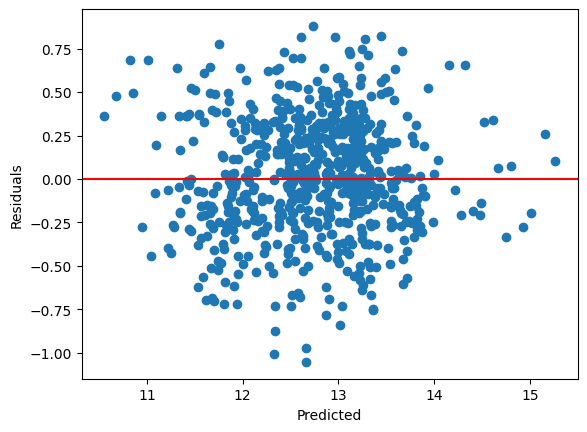

In [181]:
plt.scatter(y_pred, y_test - y_pred)
plt.axhline(0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")

Text(0.5, 1.0, 'Residuals Distribution (Histogram)')

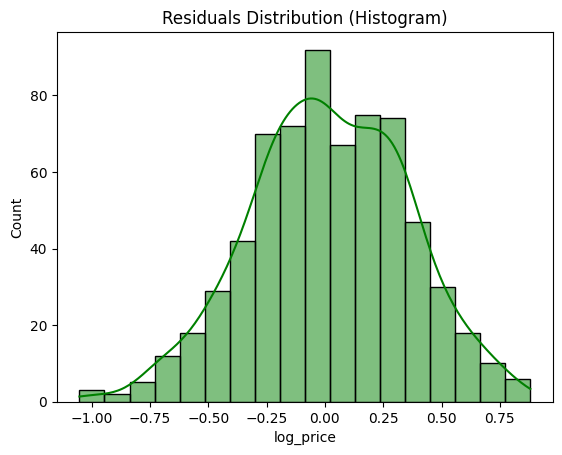

In [184]:
import seaborn as sns

residuals = y_test - y_pred

sns.histplot(residuals, kde=True, color='green')
plt.title('Residuals Distribution (Histogram)')

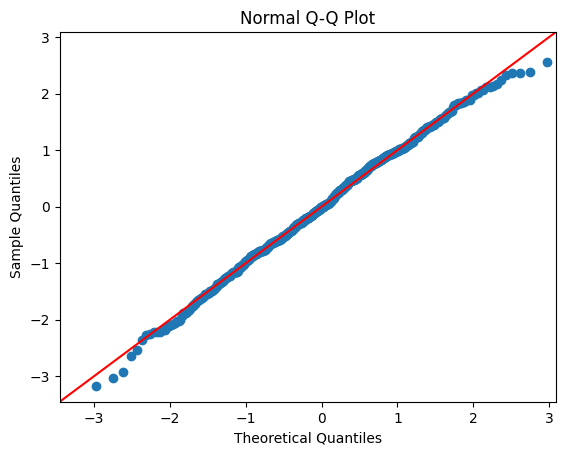

In [185]:
sm.qqplot(residuals, line='45', fit=True)
plt.title('Normal Q-Q Plot')
plt.show()